In [1]:
# If you are using google colab, you can mount your google drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Fine-tuning
This notebook demonstrates fine-tuning RamanFoundation on the Bacteria-ID dataset from Ho et al. (2019).

In [2]:
# From https://github.com/csho33/bacteria-ID
!unzip '/content/drive/My Drive/data.zip'

unzip:  cannot find or open /content/drive/My Drive/data.zip, /content/drive/My Drive/data.zip.zip or /content/drive/My Drive/data.zip.ZIP.


In [3]:
# This may be colab-specific. You may need to adapt this if you are running locally
!pip install tf_keras

!export TF_USE_LEGACY_KERAS=1
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf #importing tensorflow after setting the environment variable is important

import tensorflow as tf
import tf_keras as keras
print(tf.__version__)
print(keras.__version__)

!pip install tensorflow-addons

2.20.0
2.20.0
ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


In [4]:
import os
import numpy as np  # np.random.random
import matplotlib.pyplot as plt  # graphs
import datetime  # tensorboard logs naming

In [5]:
import os
import numpy as np

data_dir = '/content/drive/My Drive/Tesi_Raman/Datasets/Bacteria-ID/'

x_2018clinical = np.load(data_dir + 'X_2018clinical.npy')
y_2018clinical = np.load(data_dir + 'y_2018clinical.npy')
x_2019clinical = np.load(data_dir + 'X_2019clinical.npy')
y_2019clinical = np.load(data_dir + 'y_2019clinical.npy')

x_finetune = np.load(data_dir + 'X_finetune.npy')
y_finetune = np.load(data_dir + 'y_finetune.npy')

x_reference = np.load(data_dir + 'X_reference.npy')
y_reference = np.load(data_dir + 'y_reference.npy')

x_test = np.load(data_dir + 'X_test.npy')
y_test = np.load(data_dir + 'y_test.npy')

def shuffle_in_place(x, y):
  combined_data = np.column_stack((x, y))
  np.random.shuffle(combined_data)
  x_shuffled = combined_data[:, :-1]
  y_shuffled = combined_data[:, -1]
  return x_shuffled, y_shuffled


x_reference_shuffled, y_reference_shuffled = shuffle_in_place(x_reference, y_reference)
x_finetune_shuffled, y_finetune_shuffled = shuffle_in_place(x_finetune, y_finetune)
x_test_shuffled, y_test_shuffled = shuffle_in_place(x_test, y_test)

x_reference, y_reference = x_reference_shuffled, y_reference_shuffled
x_finetune, y_finetune = x_finetune_shuffled, y_finetune_shuffled
x_test, y_test = x_test_shuffled, y_test_shuffled


wavenumbers = np.load(data_dir + 'wavenumbers.npy')


In [6]:
class ResNet34Old:
    """Resnet34 class.
        Responsible for the Resnet 34 architecture.
    Modified from
    https://www.analyticsvidhya.com/blog/2021/08/how-to-code-your-resnet-from-scratch-in-tensorflow/#h2_2.
        View their website for more information.
    """
    def __init__(self):
        self.model = None

    def identity_block(self, x, filter):
        # copy tensor to variable called x_skip
        x_skip = x
        # Layer 1
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        x = tf.keras.layers.Activation("relu")(x)
        # Layer 2
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        # Add Residue
        x = tf.keras.layers.Add()([x, x_skip])
        x = tf.keras.layers.Activation("relu")(x)
        return x

    def convolutional_block(self, x, filter):
        # copy tensor to variable called x_skip
        x_skip = x
        # Layer 1
        x = tf.keras.layers.Conv1D(filter, 3, padding="same", strides=2)(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        x = tf.keras.layers.Activation("relu")(x)
        # Layer 2
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        # Processing Residue with conv(1,1)
        x_skip = tf.keras.layers.Conv1D(filter, 1, strides=2)(x_skip)
        # Add Residue
        x = tf.keras.layers.Add()([x, x_skip])
        x = tf.keras.layers.Activation("relu")(x)
        return x

    # CHANGED: Default shape to include channel dimension
    def __call__(self, shape=(1000, 1)):
        # Step 1 (Setup Input Layer)
        x_input = tf.keras.layers.Input(shape)
        x = tf.keras.layers.ZeroPadding1D(3)(x_input)
        # Step 2 (Initial Conv layer along with maxPool)
        x = tf.keras.layers.Conv1D(64, kernel_size=7, strides=2, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding="same")(x)
        # Define size of sub-blocks and initial filter size
        block_layers = [3, 4, 6, 3]
        filter_size = 64
        # Step 3 Add the Resnet Blocks
        for i in range(4):
            if i == 0:
                for j in range(block_layers[i]):
                    x = self.identity_block(x, filter_size)
            else:
                filter_size = filter_size * 2
                x = self.convolutional_block(x, filter_size)
                for j in range(block_layers[i] - 1):
                    x = self.identity_block(x, filter_size)
        # Step 4 End Dense Network
        x = tf.keras.layers.GlobalAveragePooling1D()(x)
        self.model = tf.keras.models.Model(inputs=x_input, outputs=x, name="ResNet34")
        return self.model

    @property
    def layers(self):
        if self.model is None:
            raise AttributeError("Model hasn't been built yet. Call the model first.")
        return self.model.layers


def build_twin() -> keras.Model:
    """build_twin method.

    Builds a barlow twins model consisting of an encoder(resnet-34)
    and a projector, which generates embeddings for the images

    Returns:
        returns a barlow twins model
    """

    # number of dense neurons in the projector
    n_dense_neurons = 2048

    # encoder network
    resnet = ResNet34Old()()
    # resnet = create_fresh_cnn_raman()
    last_layer = resnet.layers[-1].output

    # intermediate layers of the projector network
    n_layers = 2
    for i in range(n_layers):
        dense = tf.keras.layers.Dense(n_dense_neurons, name=f"projector_dense_{i}")
        if i == 0:
            x = dense(last_layer)
        else:
            x = dense(x)
        x = tf.keras.layers.BatchNormalization(name=f"projector_bn_{i}")(x)
        x = tf.keras.layers.ReLU(name=f"projector_relu_{i}")(x)

    x = tf.keras.layers.Dense(n_dense_neurons, name=f"projector_dense_{n_layers}")(x)

    model = keras.Model(resnet.input, x)
    return model

In [7]:
FONTSIZE_AXIS = 15
FONTSIZE_TITLE=20

In [8]:
STRAINS = {}
STRAINS[0] = "C. albicans"
STRAINS[1] = "C. glabrata"
STRAINS[2] = "K. aerogenes"
STRAINS[3] = "E. coli 1"
STRAINS[4] = "E. coli 2"
STRAINS[5] = "E. faecium"
STRAINS[6] = "E. faecalis 1"
STRAINS[7] = "E. faecalis 2"
STRAINS[8] = "E. cloacae"
STRAINS[9] = "K. pneumoniae 1"
STRAINS[10] = "K. pneumoniae 2"
STRAINS[11] = "P. mirabilis"
STRAINS[12] = "P. aeruginosa 1"
STRAINS[13] = "P. aeruginosa 2"
STRAINS[14] = "MSSA 1"
STRAINS[15] = "MSSA 3"
STRAINS[16] = "MRSA 1 (isogenic)"
STRAINS[17] = "MRSA 2"
STRAINS[18] = "MSSA 2"
STRAINS[19] = "S. enterica"
STRAINS[20] = "S. epidermidis"
STRAINS[21] = "S. lugdunensis"
STRAINS[22] = "S. marcescens"
STRAINS[23] = "S. pneumoniae 2"
STRAINS[24] = "S. pneumoniae 1"
STRAINS[25] = "S. sanguinis"
STRAINS[26] = "Group A Strep."
STRAINS[27] = "Group B Strep."
STRAINS[28] = "Group C Strep."
STRAINS[29] = "Group G Strep."

# Experiment

Here, we run the KFold Cross-Validation. The output of this code block logs the specific accuracy and losses into a text file, where summary statistics like those in Table 1 can be generated later on. We also get loss and accuracy curves similar to the ones used in Figure 7

Running finetune_pct  100 usebackbone True


------------------------------------------------------------------------
Training for fold 1 ...
Epoch 1/200
10/10 [==============================] - 38s 421ms/step - loss: 82.1362 - accuracy: 0.0296 - val_loss: 73.4445 - val_accuracy: 0.0283 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 1s 72ms/step - loss: 67.5611 - accuracy: 0.0521 - val_loss: 59.7918 - val_accuracy: 0.0433 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 1s 74ms/step - loss: 54.5896 - accuracy: 0.0962 - val_loss: 47.6961 - val_accuracy: 0.0700 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 1s 72ms/step - loss: 43.1488 - accuracy: 0.1354 - val_loss: 37.1306 - val_accuracy: 0.1050 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 1s 73ms/step - loss: 33.2294 - accuracy: 0.1579 - val_loss: 28.0771 - val_accuracy: 0.1250 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 1s 70ms/step - loss: 24.8164 - accuracy: 0.

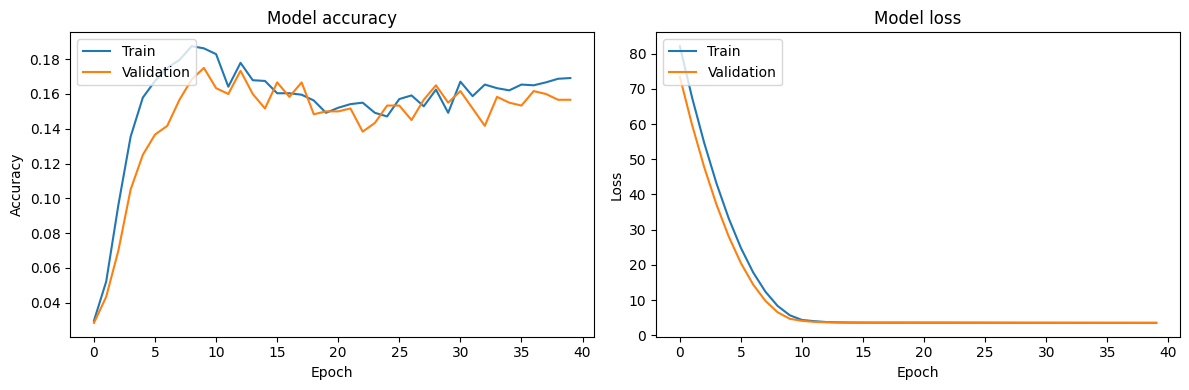

training history {'loss': [82.13617706298828, 67.56111145019531, 54.589603424072266, 43.14884567260742, 33.229393005371094, 24.8164005279541, 17.874588012695312, 12.413918495178223, 8.354499816894531, 5.689007759094238, 4.353745937347412, 4.010566234588623, 3.762695789337158, 3.6657934188842773, 3.6209566593170166, 3.6019155979156494, 3.593024492263794, 3.5904369354248047, 3.5893311500549316, 3.5877580642700195, 3.585667610168457, 3.5850353240966797, 3.5830113887786865, 3.5798499584198, 3.576294422149658, 3.5728373527526855, 3.5664165019989014, 3.5647852420806885, 3.5567309856414795, 3.552363395690918, 3.5503711700439453, 3.5456342697143555, 3.5436580181121826, 3.541900634765625, 3.540750741958618, 3.536036729812622, 3.533048152923584, 3.5338199138641357, 3.530067205429077, 3.5307116508483887], 'accuracy': [0.029583333060145378, 0.0520833320915699, 0.09624999761581421, 0.1354166716337204, 0.15791666507720947, 0.16750000417232513, 0.17499999701976776, 0.1795833259820938, 0.1875, 0.18625

------------------------------------------------------------------------
Training for fold 2 ...
Epoch 1/200
10/10 [==============================] - 32s 220ms/step - loss: 82.2792 - accuracy: 0.0379 - val_loss: 73.5610 - val_accuracy: 0.0367 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 1s 60ms/step - loss: 67.7029 - accuracy: 0.0587 - val_loss: 59.9425 - val_accuracy: 0.0333 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 1s 60ms/step - loss: 54.7383 - accuracy: 0.0763 - val_loss: 47.8526 - val_accuracy: 0.0317 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 1s 72ms/step - loss: 43.2815 - accuracy: 0.0962 - val_loss: 37.2370 - val_accuracy: 0.1033 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 1s 71ms/step - loss: 33.3204 - accuracy: 0.1437 - val_loss: 28.1469 - val_accuracy: 0.1250 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 1s 70ms/step - loss: 24.8919 - accuracy: 0.

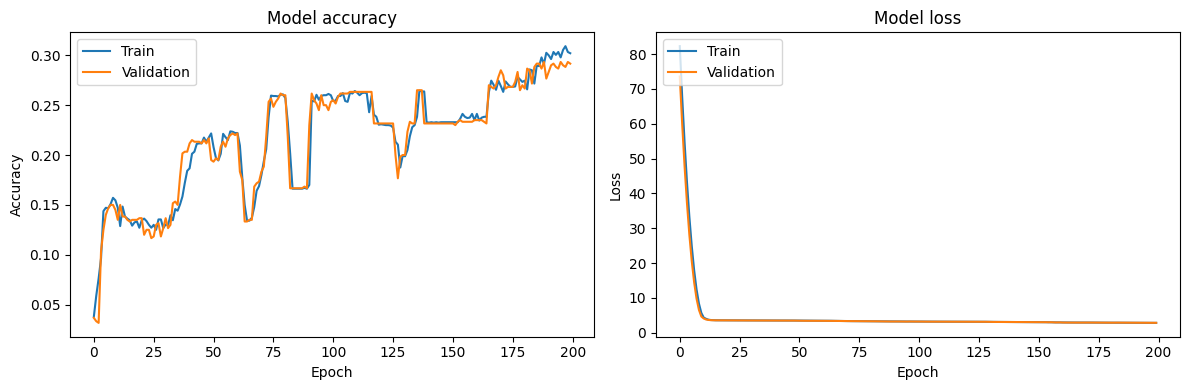

training history {'loss': [82.2791519165039, 67.70292663574219, 54.73828125, 43.281497955322266, 33.320377349853516, 24.89192008972168, 17.947763442993164, 12.462646484375, 8.39466381072998, 5.703853130340576, 4.360710620880127, 4.012396335601807, 3.7624671459198, 3.664874792098999, 3.6194698810577393, 3.6002771854400635, 3.5919811725616455, 3.5872859954833984, 3.5851452350616455, 3.583031415939331, 3.5806002616882324, 3.5786426067352295, 3.5748538970947266, 3.5726046562194824, 3.568977117538452, 3.5650641918182373, 3.561655282974243, 3.559109687805176, 3.5533385276794434, 3.550860643386841, 3.548004627227783, 3.54939866065979, 3.542766571044922, 3.5427613258361816, 3.538043737411499, 3.539508819580078, 3.535339832305908, 3.535686731338501, 3.5321602821350098, 3.531993865966797, 3.5347485542297363, 3.530595302581787, 3.527574062347412, 3.532400369644165, 3.528949499130249, 3.5277457237243652, 3.526883602142334, 3.522786855697632, 3.5222294330596924, 3.5167171955108643, 3.51392340660095

------------------------------------------------------------------------
Training for fold 3 ...
Epoch 1/200
10/10 [==============================] - 31s 222ms/step - loss: 82.2850 - accuracy: 0.0229 - val_loss: 73.5780 - val_accuracy: 0.0683 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 1s 74ms/step - loss: 67.7165 - accuracy: 0.0362 - val_loss: 59.9317 - val_accuracy: 0.0833 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 1s 61ms/step - loss: 54.7504 - accuracy: 0.0583 - val_loss: 47.8380 - val_accuracy: 0.0783 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 1s 71ms/step - loss: 43.3167 - accuracy: 0.0667 - val_loss: 37.2695 - val_accuracy: 0.0850 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 1s 73ms/step - loss: 33.3921 - accuracy: 0.0925 - val_loss: 28.2049 - val_accuracy: 0.1383 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 1s 71ms/step - loss: 24.9492 - accuracy: 0.

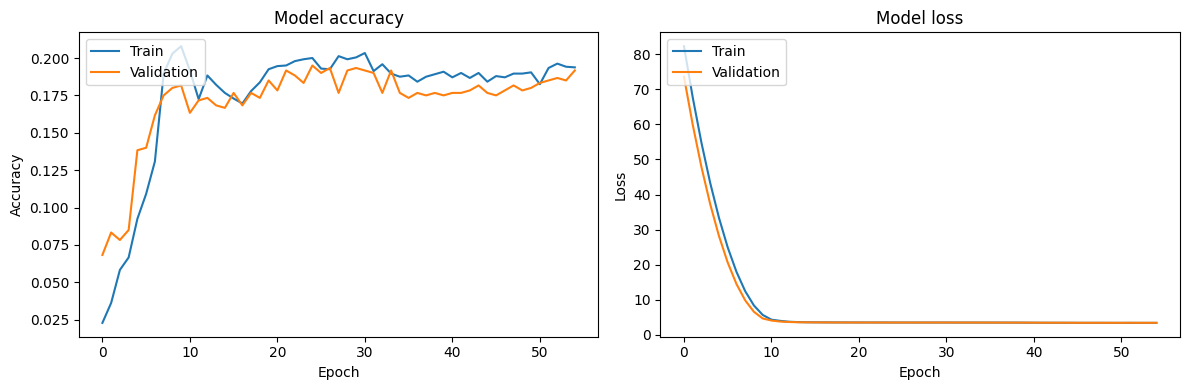

training history {'loss': [82.28496551513672, 67.71649932861328, 54.75038528442383, 43.316650390625, 33.39208984375, 24.949247360229492, 17.993711471557617, 12.4703950881958, 8.384929656982422, 5.69772481918335, 4.3528947830200195, 4.0108537673950195, 3.759878635406494, 3.6629178524017334, 3.617008924484253, 3.5955004692077637, 3.5827343463897705, 3.5713202953338623, 3.5676236152648926, 3.5600955486297607, 3.5534720420837402, 3.5520308017730713, 3.5505855083465576, 3.5479512214660645, 3.537905216217041, 3.536043643951416, 3.5348587036132812, 3.5363240242004395, 3.5351614952087402, 3.5314948558807373, 3.534660577774048, 3.526925563812256, 3.526829481124878, 3.524289608001709, 3.525134325027466, 3.5215413570404053, 3.5212182998657227, 3.5144946575164795, 3.5094096660614014, 3.496572256088257, 3.4854776859283447, 3.4737796783447266, 3.466073513031006, 3.464012861251831, 3.4615771770477295, 3.4515621662139893, 3.4435195922851562, 3.4437596797943115, 3.445476770401001, 3.437041759490967, 3.

------------------------------------------------------------------------
Training for fold 4 ...
Epoch 1/200
10/10 [==============================] - 32s 221ms/step - loss: 82.5011 - accuracy: 0.0304 - val_loss: 73.7719 - val_accuracy: 0.0383 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 1s 71ms/step - loss: 67.9069 - accuracy: 0.0433 - val_loss: 60.1194 - val_accuracy: 0.0483 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 1s 72ms/step - loss: 54.9128 - accuracy: 0.0658 - val_loss: 48.0040 - val_accuracy: 0.0617 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 1s 72ms/step - loss: 43.4337 - accuracy: 0.0983 - val_loss: 37.3984 - val_accuracy: 0.0950 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 1s 72ms/step - loss: 33.4674 - accuracy: 0.1175 - val_loss: 28.3099 - val_accuracy: 0.0983 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 1s 72ms/step - loss: 25.0137 - accuracy: 0.

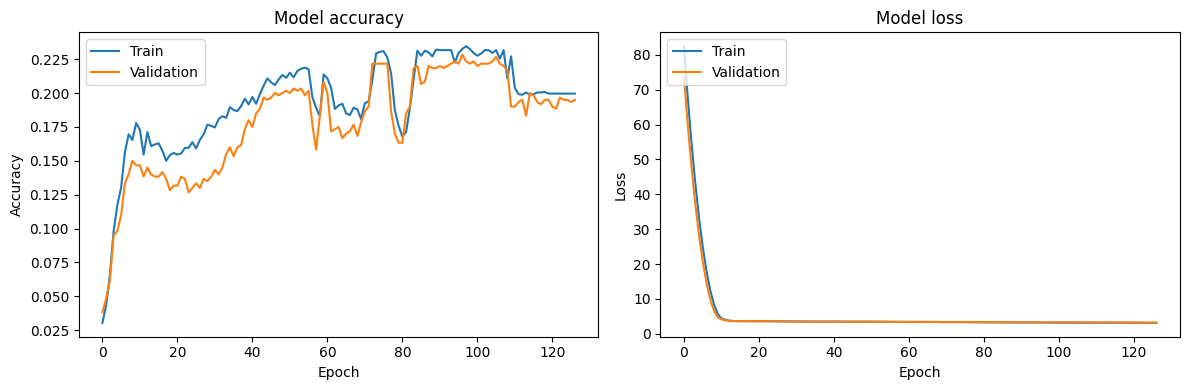

training history {'loss': [82.50110626220703, 67.90686798095703, 54.9128303527832, 43.4337272644043, 33.467376708984375, 25.0136661529541, 18.052623748779297, 12.529458999633789, 8.432635307312012, 5.715104103088379, 4.363993167877197, 4.015538692474365, 3.765239715576172, 3.667963981628418, 3.622173547744751, 3.6029951572418213, 3.5956926345825195, 3.591219902038574, 3.5897085666656494, 3.5890307426452637, 3.5882534980773926, 3.586362600326538, 3.583245038986206, 3.580087184906006, 3.5746841430664062, 3.565448522567749, 3.5559380054473877, 3.5457723140716553, 3.527325391769409, 3.5265002250671387, 3.51619029045105, 3.5107829570770264, 3.500213623046875, 3.4939913749694824, 3.490509510040283, 3.4855716228485107, 3.483797311782837, 3.481541395187378, 3.478668212890625, 3.473585605621338, 3.469888925552368, 3.468468427658081, 3.4681344032287598, 3.4606258869171143, 3.4587442874908447, 3.461850166320801, 3.456522226333618, 3.4551219940185547, 3.451070547103882, 3.4543728828430176, 3.45393

------------------------------------------------------------------------
Training for fold 5 ...
Epoch 1/200
10/10 [==============================] - 31s 220ms/step - loss: 82.5804 - accuracy: 0.0279 - val_loss: 73.8494 - val_accuracy: 0.0583 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 1s 74ms/step - loss: 67.9748 - accuracy: 0.0475 - val_loss: 60.1594 - val_accuracy: 0.0683 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 1s 61ms/step - loss: 54.9501 - accuracy: 0.0808 - val_loss: 48.0242 - val_accuracy: 0.0650 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 1s 73ms/step - loss: 43.4661 - accuracy: 0.0921 - val_loss: 37.4190 - val_accuracy: 0.1117 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 1s 72ms/step - loss: 33.4900 - accuracy: 0.1063 - val_loss: 28.3008 - val_accuracy: 0.1217 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 1s 61ms/step - loss: 25.0031 - accuracy: 0.

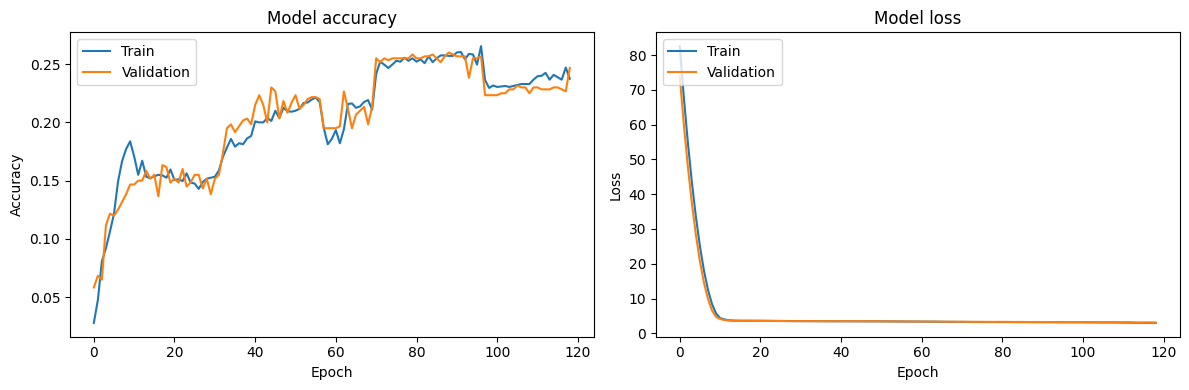

training history {'loss': [82.58036804199219, 67.97477722167969, 54.95005798339844, 43.46612548828125, 33.48996353149414, 25.00312614440918, 18.004287719726562, 12.47463607788086, 8.381475448608398, 5.698241710662842, 4.358809947967529, 4.010822296142578, 3.7624995708465576, 3.6654932498931885, 3.620926856994629, 3.601809501647949, 3.594421863555908, 3.591357946395874, 3.589571952819824, 3.587383508682251, 3.584540605545044, 3.580004930496216, 3.5718753337860107, 3.562358856201172, 3.552398204803467, 3.544750213623047, 3.531020402908325, 3.5211660861968994, 3.5122549533843994, 3.501883029937744, 3.497624158859253, 3.490851640701294, 3.485539197921753, 3.4876036643981934, 3.4754557609558105, 3.472080945968628, 3.4692223072052, 3.462432861328125, 3.4649930000305176, 3.4568607807159424, 3.463526725769043, 3.4513750076293945, 3.4521374702453613, 3.4505362510681152, 3.448014259338379, 3.4449992179870605, 3.440025568008423, 3.443321466445923, 3.443263053894043, 3.4333865642547607, 3.43159270

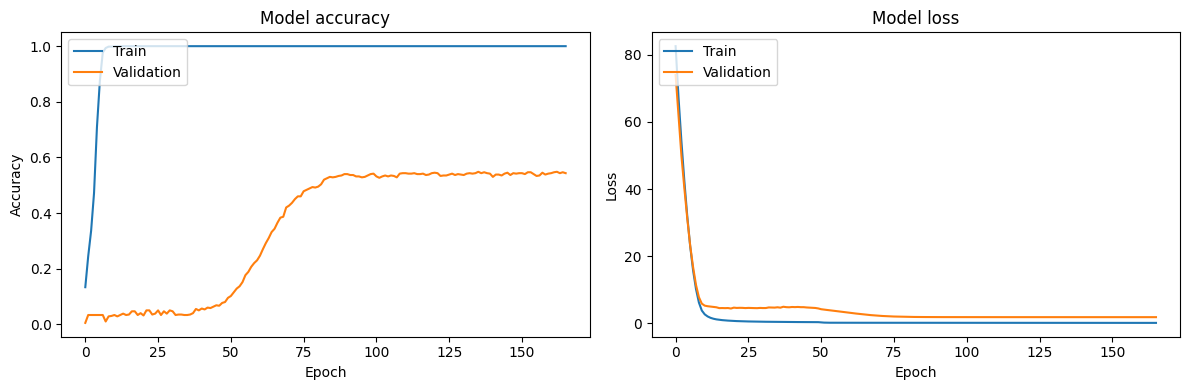

training history {'loss': [82.56999969482422, 67.285400390625, 54.18141174316406, 42.463191986083984, 31.9581356048584, 23.0583438873291, 15.811132431030273, 10.245469093322754, 6.222329139709473, 3.8405795097351074, 2.699918508529663, 2.0771520137786865, 1.6639546155929565, 1.3938838243484497, 1.2060565948486328, 1.0816643238067627, 0.9804438352584839, 0.9006151556968689, 0.8365668654441833, 0.7820316553115845, 0.7337995171546936, 0.6931382417678833, 0.6594191193580627, 0.6324527263641357, 0.6092062592506409, 0.5841222405433655, 0.5642426609992981, 0.5471765398979187, 0.5314339995384216, 0.5171931385993958, 0.5054701566696167, 0.4938257932662964, 0.48343563079833984, 0.4719819128513336, 0.46402212977409363, 0.4542209506034851, 0.4468790292739868, 0.4406619668006897, 0.43267953395843506, 0.42455074191093445, 0.41926175355911255, 0.4126150906085968, 0.40719524025917053, 0.4023943543434143, 0.39729321002960205, 0.3932596743106842, 0.3881819546222687, 0.3829641044139862, 0.379594653844833

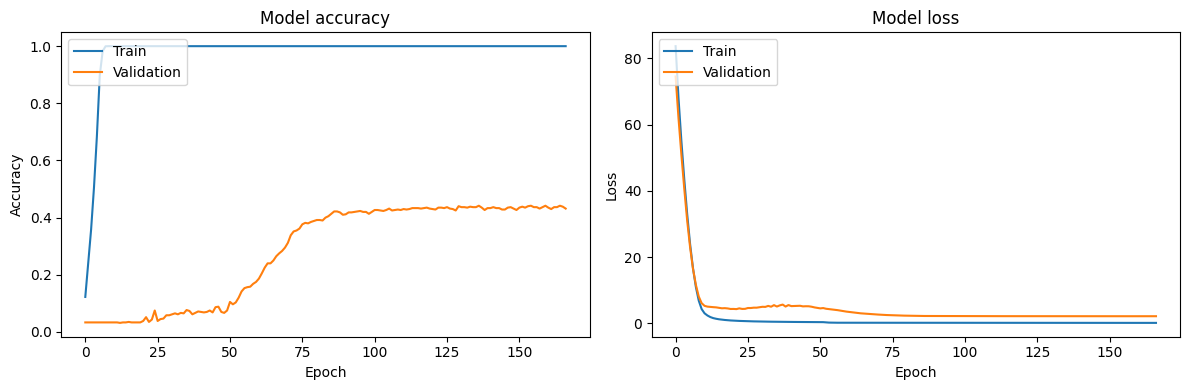

training history {'loss': [83.6505126953125, 67.99691772460938, 54.986366271972656, 43.429264068603516, 32.991455078125, 23.98819351196289, 16.70734977722168, 11.01805591583252, 6.8799147605896, 4.337040424346924, 3.0710113048553467, 2.4079322814941406, 1.9365057945251465, 1.6206341981887817, 1.4202698469161987, 1.266135811805725, 1.1567184925079346, 1.0573173761367798, 0.9768918752670288, 0.9119040966033936, 0.8605064153671265, 0.8187093734741211, 0.7741589546203613, 0.741183876991272, 0.7077555060386658, 0.6778895854949951, 0.6545396447181702, 0.6337446570396423, 0.6129966974258423, 0.595784604549408, 0.5772983431816101, 0.5624568462371826, 0.5487357974052429, 0.5357496738433838, 0.5222451090812683, 0.5142143964767456, 0.5004623532295227, 0.4912654757499695, 0.48407337069511414, 0.4764713943004608, 0.4664474427700043, 0.45957285165786743, 0.4518846273422241, 0.4438284933567047, 0.4372537136077881, 0.4310266673564911, 0.4259009063243866, 0.4224298596382141, 0.4212538003921509, 0.41528

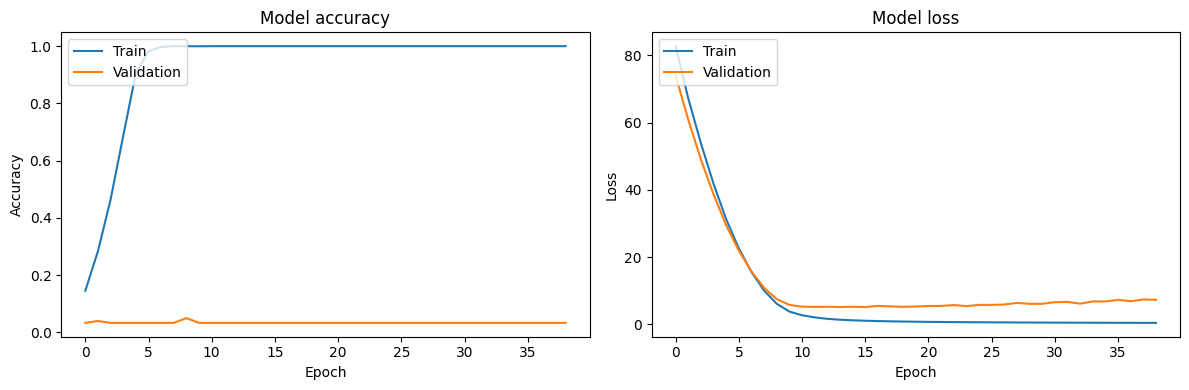

training history {'loss': [82.71002960205078, 67.19757843017578, 53.8651123046875, 41.79743957519531, 31.25060272216797, 22.593523025512695, 15.563896179199219, 10.043911933898926, 6.114844799041748, 3.7996509075164795, 2.702148199081421, 2.0712273120880127, 1.6465423107147217, 1.3737366199493408, 1.1996982097625732, 1.0743037462234497, 0.9717651605606079, 0.8931700587272644, 0.8323138356208801, 0.7813883423805237, 0.7377297878265381, 0.7009152173995972, 0.6683382391929626, 0.6414450407028198, 0.6153121590614319, 0.5951089859008789, 0.57452791929245, 0.5557271838188171, 0.5396539568901062, 0.5255024433135986, 0.512061357498169, 0.4993270933628082, 0.4904378652572632, 0.47819849848747253, 0.4676284193992615, 0.4592844247817993, 0.44910919666290283, 0.4404354989528656, 0.43307435512542725], 'accuracy': [0.14541666209697723, 0.2837499976158142, 0.46416667103767395, 0.6862499713897705, 0.9054166674613953, 0.9820833206176758, 0.9975000023841858, 1.0, 1.0, 0.9995833039283752, 1.0, 1.0, 1.0, 

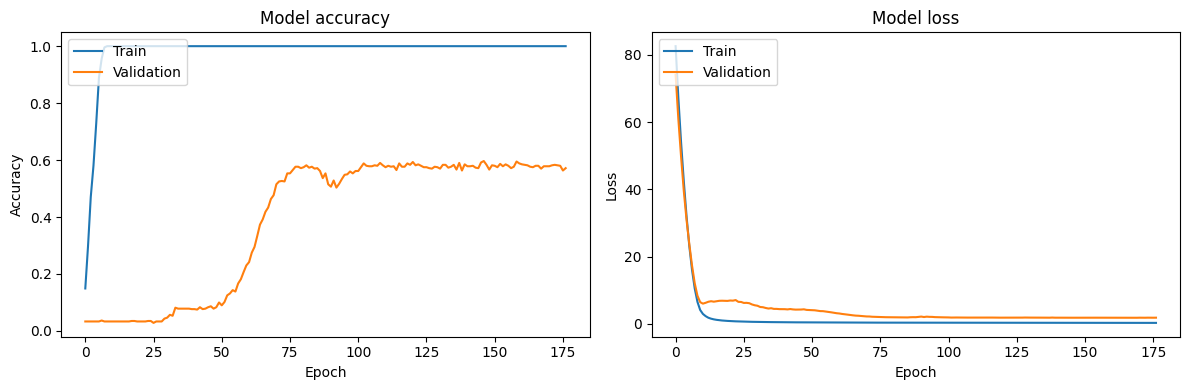

training history {'loss': [82.59814453125, 67.30481719970703, 54.02947235107422, 42.418678283691406, 32.08566665649414, 23.26020050048828, 16.123218536376953, 10.505300521850586, 6.506771564483643, 4.089845657348633, 2.9154281616210938, 2.2541120052337646, 1.7806951999664307, 1.4985325336456299, 1.3013068437576294, 1.1559535264968872, 1.0459792613983154, 0.9614639282226562, 0.8928985595703125, 0.8368121981620789, 0.7891212701797485, 0.7458101511001587, 0.7110264301300049, 0.6818915009498596, 0.6505060195922852, 0.6284387111663818, 0.6053364872932434, 0.5852490067481995, 0.5663653016090393, 0.5496164560317993, 0.534410834312439, 0.5206199884414673, 0.5096222162246704, 0.49905532598495483, 0.4871426820755005, 0.4791412949562073, 0.4686960279941559, 0.45978400111198425, 0.45140838623046875, 0.44446679949760437, 0.438432514667511, 0.4313535988330841, 0.42728012800216675, 0.4201127886772156, 0.41446834802627563, 0.41032880544662476, 0.4068620502948761, 0.4010576009750366, 0.3955800235271454

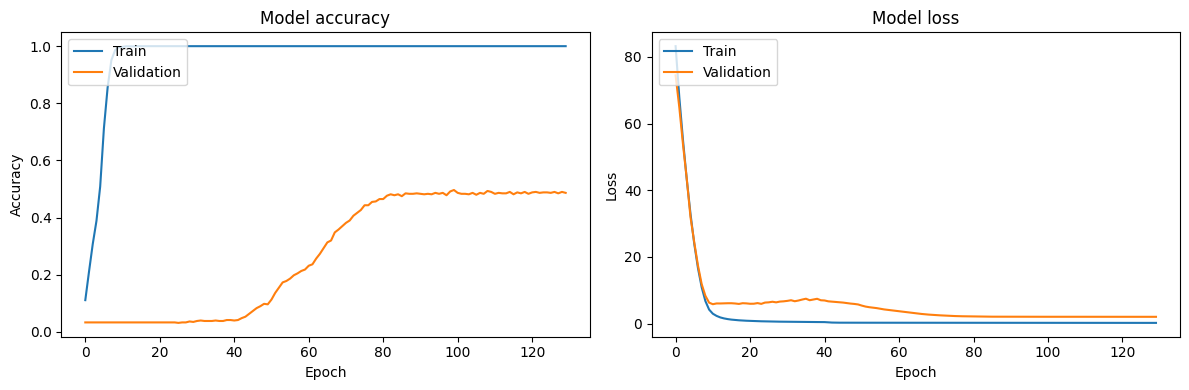

training history {'loss': [83.24361419677734, 67.83293151855469, 54.85624313354492, 43.21613311767578, 32.91363525390625, 24.002464294433594, 16.668289184570312, 10.89168930053711, 6.744394779205322, 4.188960552215576, 2.9576926231384277, 2.3005311489105225, 1.8442118167877197, 1.5494375228881836, 1.340541124343872, 1.1872941255569458, 1.0735543966293335, 0.9825868010520935, 0.909641444683075, 0.8529374599456787, 0.8038275837898254, 0.7610226273536682, 0.7221147418022156, 0.6873679757118225, 0.6577900052070618, 0.6327047944068909, 0.6100792288780212, 0.5896747708320618, 0.5714874267578125, 0.5569763779640198, 0.5401824712753296, 0.5256348252296448, 0.512564480304718, 0.5037903785705566, 0.4913639426231384, 0.4805111587047577, 0.47319766879081726, 0.4643639624118805, 0.45715078711509705, 0.44976210594177246, 0.44137200713157654, 0.3667881190776825, 0.30267763137817383, 0.2772020995616913, 0.2663712203502655, 0.2608352601528168, 0.25934407114982605, 0.257499098777771, 0.2604072391986847,

In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import random
import os
import numpy as np
import tensorflow as tf

# Imposta i seed per la riproducibilità
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # tf.config.experimental.enable_op_determinism() # Rimuovi il commento per un determinismo assoluto (può rallentare il training)

set_seeds(42)

temp_model = -1

def do_experiment(finetune_percent = 0.2, use_selfsupervised_backbone = True, nfolds_to_test=5):
  use_reference_warmup = False  # should we train few epochs with x_reference


  if finetune_percent < 1.0:
    xtrainpct, xtestpct, ytrainpct, ytestpct = train_test_split(x_finetune, y_finetune,
                                                                train_size=finetune_percent, random_state=42,
                                                                stratify=y_finetune,
                                                                shuffle=True)
    x_finetune_select, y_finetune_select = xtrainpct, ytrainpct
  else:
    x_finetune_select, y_finetune_select = x_finetune, y_finetune


  # fold validation and testing
  num_folds=5
  kfold = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

  # K-fold Cross Validation model evaluation
  fold_no = 1
  for train_indices, val_indices in kfold.split(x_finetune_select, y_finetune_select):
      # Generate batches from indices
      xtrain, xval = x_finetune_select[train_indices], x_finetune_select[val_indices]
      ytrain, yval = y_finetune_select[train_indices], y_finetune_select[val_indices]
      if use_selfsupervised_backbone:
        # CARICAMENTO DEL TUO MODELLO PRE-ADDESTRATO
        bm_model_loaded = keras.models.load_model("/content/drive/My Drive/Tesi_Raman/Models/PreTrain/BarlowTwins/1000pt/FullRange/Min-Max/exp_2/ramanfoundation_pretrained_model.h5")
      else:
        bm_model_loaded = build_twin() # use random weights model

      # Do not freeze weights
      model = tf.keras.models.Sequential([
        bm_model_loaded,
        tf.keras.layers.Dense(
            30,
            activation="softmax",
            kernel_regularizer=tf.keras.regularizers.L1L2(0.05,0.05)
        )
      ])

      # Generate a print
      print('------------------------------------------------------------------------')
      print(f'Training for fold {fold_no} ...')

      if use_reference_warmup:
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.5, beta_2=0.999), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        history=model.fit(x_reference, y_reference, batch_size=512, epochs=5,
                                          callbacks=[
                                keras.callbacks.EarlyStopping(
                                    monitor='val_accuracy',
                                    patience=10,
                                    restore_best_weights=True
                                ),
                                keras.callbacks.ReduceLROnPlateau(
                                    monitor='val_loss',
                                    factor=0.1,
                                    patience=30,
                                    min_lr=0.0000005
                                )
                            ], validation_split=0.2
        )

        # Plot training history
        import matplotlib.pyplot as plt

        plt.figure(figsize=(12, 4))

        # Plot training & validation accuracy
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'])
        plt.plot(history.history['val_accuracy'])
        plt.title('Model accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')

        # Plot training & validation loss
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'])
        plt.plot(history.history['val_loss'])
        plt.title('Model loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')

        plt.tight_layout()
        plt.show()

        print("train with xref and yref light")
        model.evaluate(x_test, y_test)

      model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0005, beta_1=0.9, beta_2=0.999), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

      history = model.fit(xtrain, ytrain,
                          validation_data=(xval, yval),
                          # 256
                          batch_size=256,
                          epochs=200,
                          callbacks=[
                              keras.callbacks.EarlyStopping(
                                  monitor='val_accuracy',
                                  patience=30,
                                  restore_best_weights=True
                              ),
                              keras.callbacks.ReduceLROnPlateau(
                                  monitor='val_loss',
                                  factor=0.1,
                                  patience=30,
                                  min_lr=0.0000005
                              )
                          ]
                          #validation_split=0.2
                          )

      # Plot training history
      import matplotlib.pyplot as plt
      plt.figure(figsize=(12, 4))

      # Plot training & validation accuracy
      plt.subplot(1, 2, 1)
      plt.plot(history.history['accuracy'])
      plt.plot(history.history['val_accuracy'])
      plt.title('Model accuracy')
      plt.ylabel('Accuracy')
      plt.xlabel('Epoch')
      plt.legend(['Train', 'Validation'], loc='upper left')

      # Plot training & validation loss
      plt.subplot(1, 2, 2)
      plt.plot(history.history['loss'])
      plt.plot(history.history['val_loss'])
      plt.title('Model loss')
      plt.ylabel('Loss')
      plt.xlabel('Epoch')
      plt.legend(['Train', 'Validation'], loc='upper left')

      plt.tight_layout()
      plt.show()
      history_str = str(history.history)
      print (f"training history {history_str}")


      result = model.evaluate(x_test, y_test)
      result_str = "test loss, test acc:" + str(result)
      print(f"Result: use backbone : {use_selfsupervised_backbone}, test_accuracy finetune_percent {finetune_percent}, fold_number {fold_no}, test_results {result_str}")
      result_dict = dict(zip(model.metrics_names, result))
      result_dict_str = str(result_dict)
      print(result_dict_str)

      # save result_dict_str into a txt file
      file_name = f"result_{int(finetune_percent * 100)}_backbone_{use_selfsupervised_backbone}"

      # Save the string to a file
      with open(file_name, "a") as file:
          file.write("\n"+result_dict_str)

      print(f"String saved to {file_name}")

      # You can utilize temp_model for creating certain plots like confusion matricies
      global temp_model
      temp_model = model

      fold_no = fold_no + 1
      if fold_no > nfolds_to_test:
        return

# Esegue solo per il 100% dei dati
for pct in [100]:
  for usebackbone in [True, False]:
    print (f"Running finetune_pct  {pct} usebackbone {usebackbone}")
    do_experiment(pct/100.0, usebackbone,  nfolds_to_test=5)


In [10]:
import ast
import os
import numpy as np

print("=== AVERAGE ACCURACY SUMMARY ===\n")

# Analizza solo il file dei risultati per il 100% dei dati
for pct in [100]:
    for usebackbone in [True, False]:
        file_name = f"result_{pct}_backbone_{usebackbone}"
        if os.path.exists(file_name):
            with open(file_name, "r") as f:
                lines = f.readlines()
                accuracies = []
                for line in lines:
                    line = line.strip()
                    if line:
                        try:
                            # Convert the dictionary string into a real Python dictionary
                            result_dict = ast.literal_eval(line)
                            accuracies.append(result_dict['accuracy'])
                        except:
                            pass

                if accuracies:
                    avg_acc = np.mean(accuracies)
                    std_acc = np.std(accuracies)
                    print(f"-> Data used: {pct}% | Pre-trained (Backbone): {usebackbone}")
                    print(f"   Average Test Accuracy: {avg_acc*100:.2f}% (± {std_acc*100:.2f}%)\n")
        else:
            print(f"File {file_name} not found.\n")


=== AVERAGE ACCURACY SUMMARY ===

-> Data used: 100% | Pre-trained (Backbone): True
   Average Test Accuracy: 19.45% (± 3.28%)

-> Data used: 100% | Pre-trained (Backbone): False
   Average Test Accuracy: 35.43% (± 15.87%)



In [11]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 20}) # Adjust the value (20) as needed

Confusion matrix plot used in Figure 8

94/94 [==============================] - 2s 7ms/step


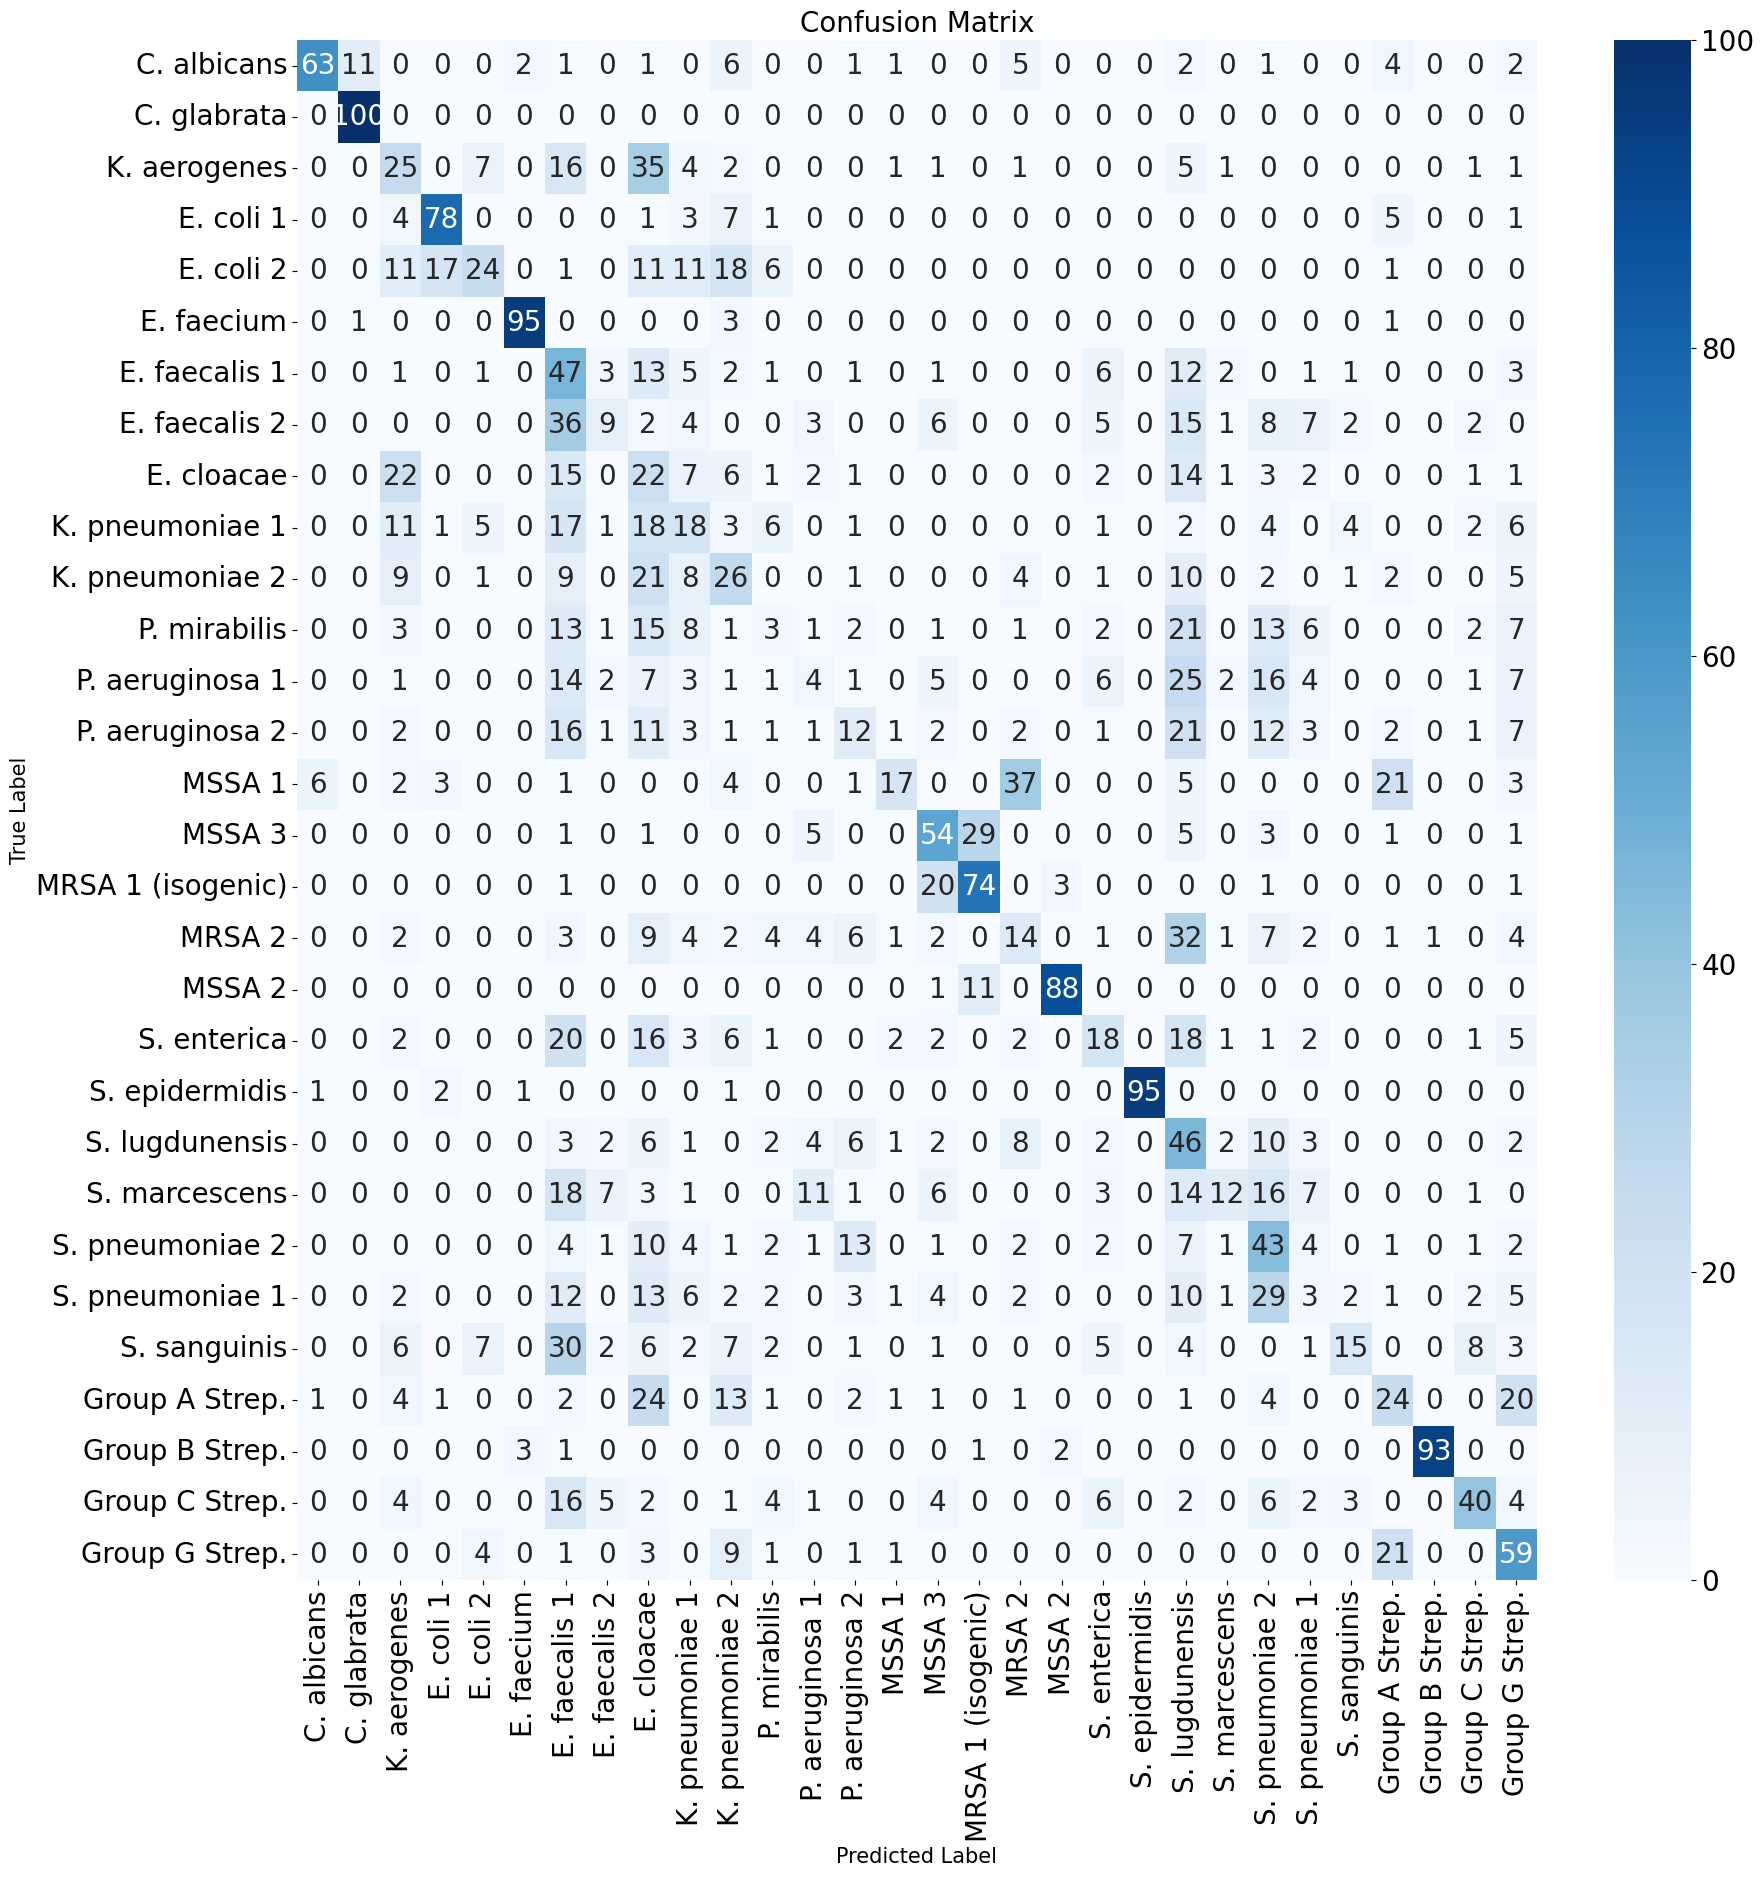

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


y_pred = np.argmax(temp_model.predict(x_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[STRAINS[i] for i in range(30)],
            yticklabels=[STRAINS[i] for i in range(30)])
plt.xlabel("Predicted Label", fontsize=FONTSIZE_AXIS)
plt.ylabel("True Label", fontsize=FONTSIZE_AXIS)
plt.title("Confusion Matrix", fontsize=FONTSIZE_TITLE)
plt.show()